----------------------------------------------------------------------------------------
1. Import libraries 
----------------------------------------------------------------------------------------

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.optimize import minimize

----------------------------------------------------------------------------------------
2. Load csv data (5 years)
----------------------------------------------------------------------------------------

In [2]:
folder_path = "/Users/federidogaravaglia/Desktop/Backup/csv"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

all_returns = []

for file in csv_files:
    df = pd.read_csv(file, parse_dates=["Date"], dayfirst=True)
    df = df.sort_values("Date")

    price_col = "Close" if "Close" in df.columns else "Close"

    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    df["Return"] = df[price_col].pct_change(fill_method=None)

    stock_name = os.path.basename(file).replace(".csv", "")
    df = df[["Date", "Return"]].rename(columns={"Return": stock_name})
    
    all_returns.append(df)

combined = all_returns[0]
for df in all_returns[1:]:
    combined = pd.merge(combined, df, on="Date", how="outer")

combined = combined.sort_values("Date")

start_date = "2021-01-01"
end_date = "2026-01-01"

mask = (combined["Date"] >= start_date) & (combined["Date"] <= end_date)
combined_filtered = combined.loc[mask]

# print(combined_filtered.head())

----------------------------------------------------------------------------------------
3. Cleaning data - For missing data forward-filling has been used to avoid look-ahead bias.
----------------------------------------------------------------------------------------

In [3]:
df.set_index("Date", inplace=True)
# print(combined_filtered.isnull().sum())
combined_filtered = combined_filtered.sort_index()
combined_filtered = combined_filtered.ffill()
# combined_filtered = combined_filtered.interpolate(method="linear") 
# print(combined_filtered.isnull().sum())
# combined_filtered.head()


----------------------------------------------------------------------------------------
4. Compute and plot cumulative returns
----------------------------------------------------------------------------------------

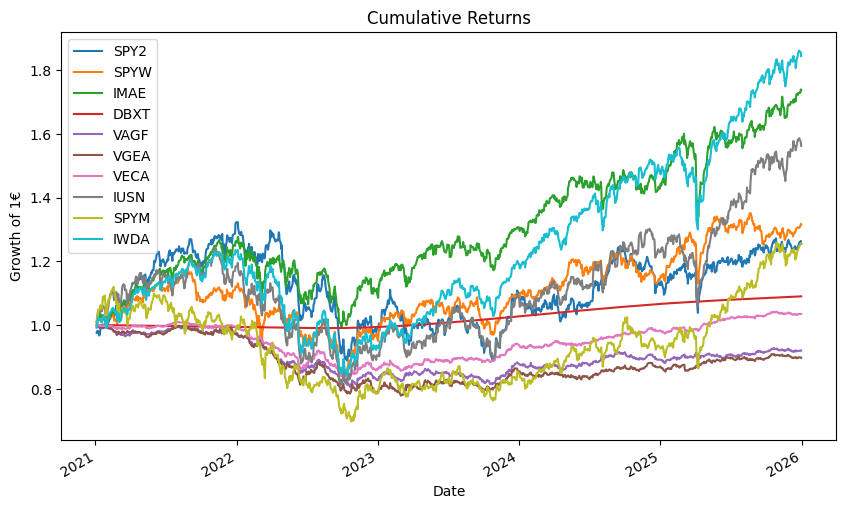

In [4]:
combined_filtered["Date"] = pd.to_datetime(combined_filtered["Date"])
combined_filtered.set_index("Date", inplace=True)
returns = combined_filtered
cumulative_returns = (1 + returns).cumprod() 
# cumulative_returns.tail() 
cumulative_returns.plot(figsize = (10, 6)) 
plt.title("Cumulative Returns") 
plt.xlabel("Date")
plt.ylabel("Growth of 1€")
# plt.show()
plt.savefig("../outputs/charts/assets_cumulative_returns.png", dpi=300)
# plt.close()

----------------------------------------------------------------------------------------
5. Compute portfolio return (cumulative, total, CAGR) and annualized volatility - dot product between the returns matrix and the weight vector to obtain the time-series of portfolio returns
----------------------------------------------------------------------------------------

In [5]:
# weights = np.array([0.07, 0.06, 0.15, 0.03, 0.06, 0.03, 0.06, 0.10, 0.08, 0.36])
weights = np.repeat(1 / len(returns.columns), len(returns.columns))
# print(weights.sum())
portfolio_returns = returns.dot(weights) 
portfolio_returns.head()
# same as portfolio_returns = (returns * weights).sum(axis=1)
portfolio_cumulative_returns = (1 + portfolio_returns).cumprod() 
total_return = portfolio_cumulative_returns.iloc[-1] - 1
# print(total_return)
n_days = len(portfolio_returns)
n_years = n_days / 252
final_value = portfolio_cumulative_returns.iloc[-1] 
cagr = final_value ** (1 / n_years) - 1
# print(cagr)
volatility = portfolio_returns.std() * np.sqrt(252)
# print(volatility)

----------------------------------------------------------------------------------------
6. Compute annualized portfolio and assets Sharpe (hp, rf = 3%, €STR 2-4%)
----------------------------------------------------------------------------------------

In [6]:
risk_free = 0.03
rf_daily = risk_free / 252
mean_returns = returns.mean() * 252
excess_returns = portfolio_returns - rf_daily
sharpe_ratio = (excess_returns.mean() * 252) / volatility
rolling_sharpe = (portfolio_returns.rolling(252).mean() * 252) / (portfolio_returns.rolling(252).std() * np.sqrt(252))
# print(sharpe_ratio)
asset_excess_returns = returns - rf_daily
asset_sharpe = (asset_excess_returns.mean() * 252) / (returns.std() * np.sqrt(252)) 
asset_sharpe_df = asset_sharpe.sort_values(ascending=False).to_frame(name="Sharpe Ratio") 
asset_sharpe_df.index.name = "Asset"
asset_sharpe_df["Sharpe Ratio"] = asset_sharpe_df["Sharpe Ratio"].round(2)
# print(asset_sharpe_df)

----------------------------------------------------------------------------------------
7. Compute portfolio max drawdown
----------------------------------------------------------------------------------------

In [7]:
running_max = portfolio_cumulative_returns.cummax()
drawdown = (portfolio_cumulative_returns - running_max) / running_max 
max_drawdown = drawdown.min()
# print(max_drawdown)

----------------------------------------------------------------------------------------
8. Portfolio visualizations (cumulative returns, drawdown)
----------------------------------------------------------------------------------------

<Figure size 1000x600 with 0 Axes>

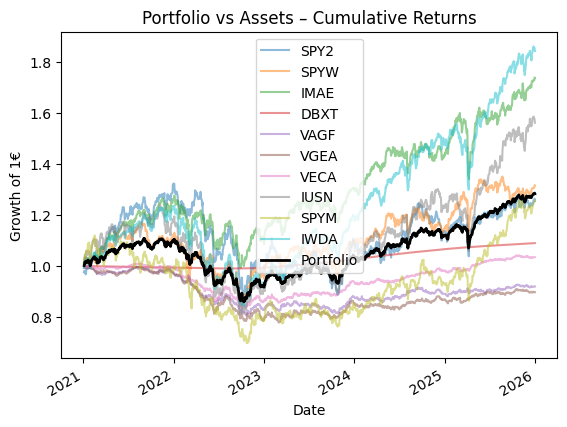

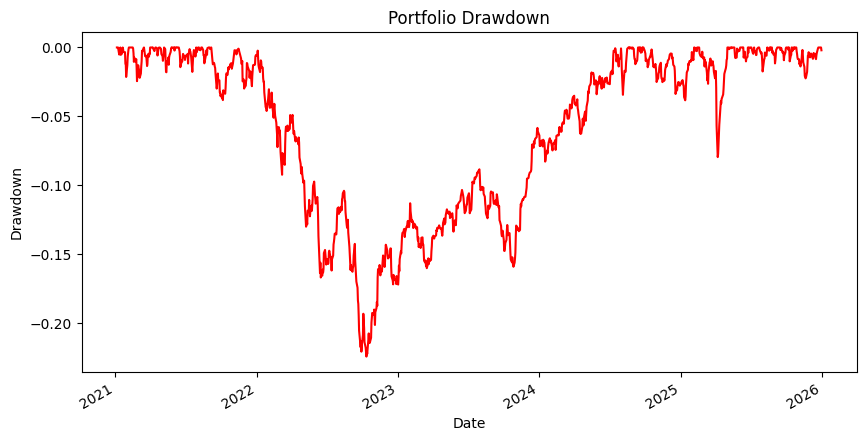

In [8]:
plt.figure(figsize = (10, 6))
cumulative_returns.plot(alpha = 0.5)
portfolio_cumulative_returns.plot(color = "black", linewidth = 2, label = "Portfolio") 
plt.title("Portfolio vs Assets – Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of 1€")
plt.legend()
# plt.show()
plt.savefig("../outputs/charts/portfolio_vs_assets_cum.png", dpi=300)
# plt.close()
plt.figure(figsize = (10, 5))
drawdown.plot(color = "red")
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
# plt.show()
plt.savefig("../outputs/charts/portfolio_drawdown.png", dpi=300)
# plt.close()

----------------------------------------------------------------------------------------
9. Attribution (risk, factors)
----------------------------------------------------------------------------------------

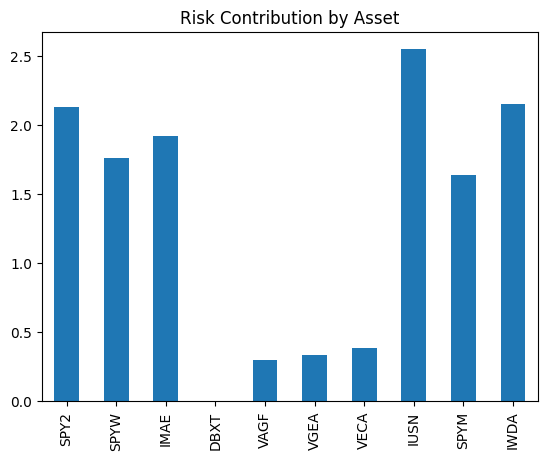

In [9]:
cov_matrix = returns.cov() * 252
portfolio_var = weights.T @ cov_matrix @ weights
marginal_contribution = cov_matrix @ weights
risk_contribution = weights * marginal_contribution / portfolio_var
risk_contribution_pct = risk_contribution / volatility
risk_contribution_df = pd.DataFrame({"Weight": weights, "Risk Contribution": risk_contribution, "Risk Contribution %": risk_contribution_pct}, index=returns.columns)
risk_contribution_df["Risk Contribution %"].plot(kind="bar")
plt.title("Risk Contribution by Asset")
plt.savefig("../outputs/charts/assets_risk_contribution.png", dpi=300)

----------------------------------------------------------------------------------------
10. [Benchmark] – Load and clean data
----------------------------------------------------------------------------------------

In [10]:
benchmark_prices = pd.read_csv("/Users/federidogaravaglia/Desktop/Backup/csv/IWDA.csv")
benchmark_prices.head()
benchmark_prices["Close"] = pd.to_numeric(benchmark_prices["Close"], errors="coerce")
benchmark_prices["Date"] = pd.to_datetime(benchmark_prices["Date"], dayfirst=True)
# benchmark_prices["Close"].dtype
# print(benchmark_prices.isnull().sum())
benchmark_prices.set_index("Date", inplace=True)
benchmark_prices = benchmark_prices.sort_index()
benchmark_prices = benchmark_prices.ffill()
benchmark_prices = benchmark_prices.infer_objects(copy=False)
benchmark_prices = benchmark_prices.interpolate(method="linear") 
# print(benchmark_prices.isnull().sum())
# benchmark_prices.head()
benchmark_filtered = benchmark_prices.loc["2021-01-01":"2026-01-01"]
# benchmark_filtered.head(100)

----------------------------------------------------------------------------------------
11. [Benchmark] – Compute and compare cumulative returns
----------------------------------------------------------------------------------------

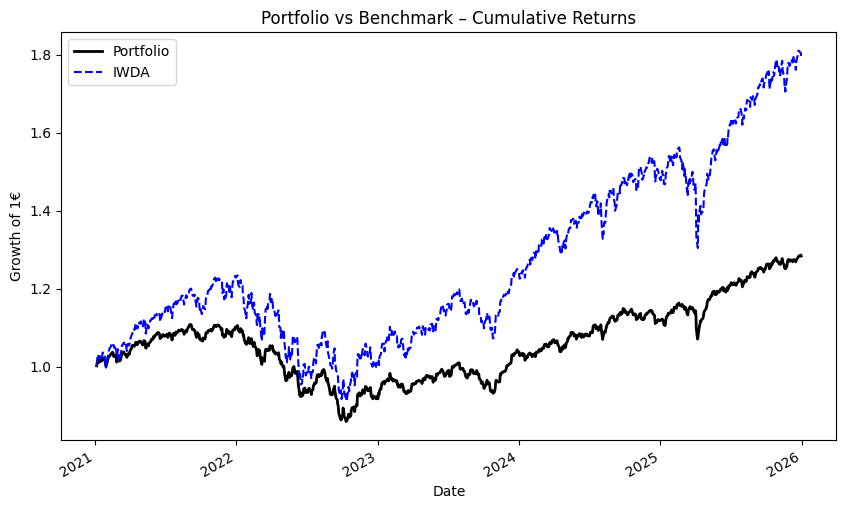

In [11]:
benchmark_returns = benchmark_filtered["Close"].pct_change().dropna() 
benchmark_cumulative_returns = (1 + benchmark_returns).cumprod() 
total_benchmark_return = benchmark_cumulative_returns.iloc[-1] - 1 
benchmark_final_value = benchmark_cumulative_returns.iloc[-1] 
benchmark_cagr = benchmark_final_value**(1 / n_years) - 1 
plt.figure(figsize = (10,6))
portfolio_cumulative_returns.plot(color = "black", linewidth = 2, label = "Portfolio") 
benchmark_cumulative_returns.plot(color = "blue", linestyle = "--", label = "IWDA") 
plt.title("Portfolio vs Benchmark – Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of 1€")
plt.legend()
# plt.show() 
plt.savefig("../outputs/charts/portfolio_vs_benchmark.png", dpi=300) 
# plt.close()

----------------------------------------------------------------------------------------
12. [Benchmark] – Compute and compare Sharpe ratios
----------------------------------------------------------------------------------------

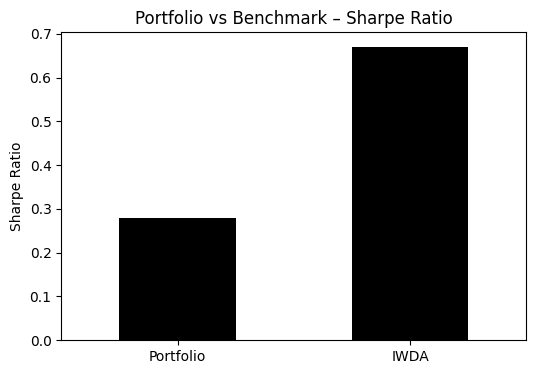

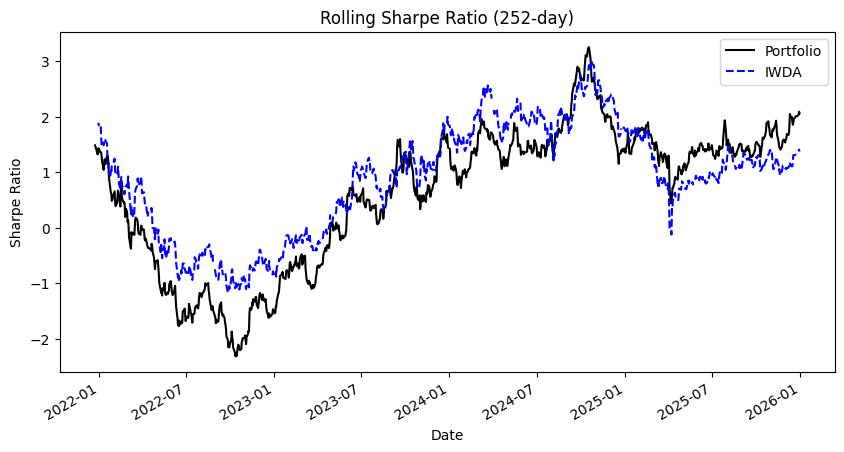

In [13]:
benchmark_excess = benchmark_returns - rf_daily
benchmark_volatility = benchmark_returns.std() * np.sqrt(252)
benchmark_sharpe = (benchmark_excess.mean() * 252) / benchmark_volatility
benchmark_rolling_sharpe = (benchmark_returns.rolling(252).mean() * 252) / (benchmark_returns.rolling(252).std() * np.sqrt(252))
sharpe_comparison = pd.DataFrame({"Sharpe Ratio": [sharpe_ratio, benchmark_sharpe]}, index=["Portfolio", "IWDA"])
sharpe_comparison = sharpe_comparison.round(2)
# print(sharpe_comparison)
sharpe_comparison.plot(kind="bar", figsize=(6,4), legend=False, color=["black", "blue"]) 
plt.title("Portfolio vs Benchmark – Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=0)
# plt.show()
plt.savefig("../outputs/charts/sharpe_comparison.png", dpi=300)
# plt.close()
rolling_sharpe_comparison = pd.DataFrame({"Rolling Sharpe Ratio": [rolling_sharpe, benchmark_rolling_sharpe]}, index=["Portfolio", "IWDA"])
rolling_sharpe_comparison = rolling_sharpe_comparison.round(2)
# print(sharpe_comparison)
rolling_sharpe_comparison = pd.DataFrame({"Portfolio": rolling_sharpe, "IWDA": benchmark_rolling_sharpe})
rolling_sharpe_comparison.plot(figsize=(10,5), style={"Portfolio": "k-", "IWDA": "b--"})
plt.title("Rolling Sharpe Ratio (252-day)")
plt.ylabel("Sharpe Ratio")
plt.savefig("../outputs/charts/rolling_sharpe_comparison.png", dpi=300)
# plt.show()
plt.savefig("../outputs/charts/sharpe_comparison.png", dpi=300)
# plt.close()

----------------------------------------------------------------------------------------
13. [Benchmark] – Compute and compare max drawdown
----------------------------------------------------------------------------------------

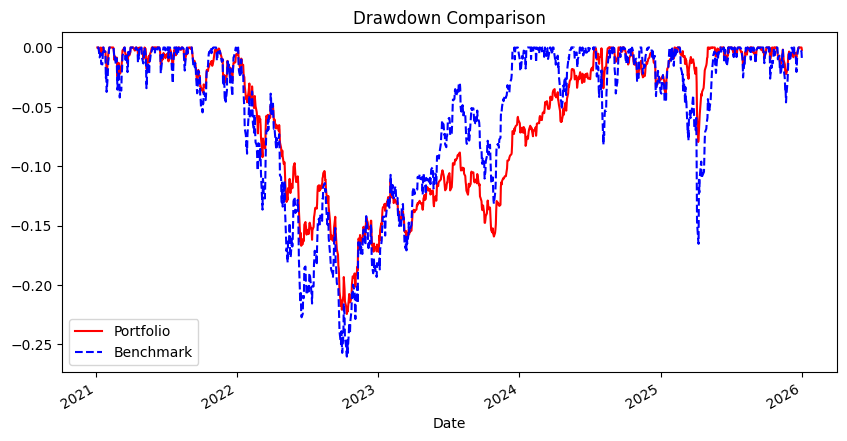

In [15]:
benchmark_running_max = benchmark_cumulative_returns.cummax()
benchmark_drawdown = (benchmark_cumulative_returns - benchmark_running_max) / benchmark_running_max
max_benchmark_drawdown = benchmark_drawdown.min()
max_drawdown_comparison = pd.DataFrame({"Max Drawdown": [drawdown.min(),benchmark_drawdown.min()]}, index=['Portfolio', "IWDA"])
max_drawdown_comparison = max_drawdown_comparison.round(2)
# print(max_drawdown_comparison)
plt.figure(figsize = (10,5))
drawdown.plot(label = "Portfolio", color = "red") 
benchmark_drawdown.plot(label = "Benchmark", color = "blue", linestyle = "--") 
plt.title("Drawdown Comparison")
plt.legend()
# plt.show()
plt.savefig("../outputs/charts/drawdown_comparison.png", dpi=300)
# plt.close()

----------------------------------------------------------------------------------------
14. Outcome Portfolio vs Benchmark
----------------------------------------------------------------------------------------

In [16]:
sharpe_tolerance = 0.05
drawdown_tolerance = 0.01
sharpe_difference = sharpe_ratio - benchmark_sharpe 
rolling_sharpe_difference = (rolling_sharpe.mean() - benchmark_rolling_sharpe.mean())
drawdown_difference = max_benchmark_drawdown - max_drawdown
concentration = risk_contribution_pct.max()
if sharpe_difference > sharpe_tolerance:
    sharpe_result = "Portfolio outperformed the Benchmark"
elif sharpe_difference < -sharpe_tolerance:
    sharpe_result = "Portfolio underperformed the Benchmark" 
else:
    sharpe_result = "Portfolio performed in line with the Benchmark" 
if rolling_sharpe_difference > sharpe_tolerance:
    rolling_sharpe_result = "Portfolio outperformed the Benchmark"
elif rolling_sharpe_difference < -sharpe_tolerance:
    rolling_sharpe_result = "Portfolio underperformed the Benchmark" 
else:
    rolling_sharpe_result = "Portfolio performed in line with the Benchmark"
if drawdown_difference > drawdown_tolerance:
    drawdown_result = "Portfolio had worse downside than the Benchmark"
elif drawdown_difference < - drawdown_tolerance:
    drawdown_result = "Portfolio had better downside protection than the Benchmark"
else:
    drawdown_result = "Portfolio drawdown was in line with the Benchmark"
if concentration > 0.4:
    risk_result = "Portfolio risk is highly concentrated"
elif concentration < 0.2:
    risk_result = "Portfolio risk is well diversified"
else:
    risk_result = "Portfolio has moderate risk concentration"

----------------------------------------------------------------------------------------
15. Portfolio optimization (Max Sharpe)
----------------------------------------------------------------------------------------

In [17]:
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free):
    portfolio_return = weights @ mean_returns
    portfolio_vol = np.sqrt(weights @ cov_matrix @ weights)
    sharpe = (portfolio_return - risk_free) / portfolio_vol
    return portfolio_return, portfolio_vol, sharpe
def negative_sharpe(weights, mean_returns, cov_matrix, risk_free):
    return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free)[2]

num_assets = len(mean_returns)
constraints_sharpe = ({"type": "eq", "fun": lambda w: np.sum(w) - 1})
bounds_sharpe = tuple((0, 1) for _ in range(num_assets))  # long only
bounds_sharpe = tuple((0, 0.3) for _ in range(num_assets)) # max 30% weight


----------------------------------------------------------------------------------------
16. Run Optimization (Max Sharpe)
----------------------------------------------------------------------------------------

In [18]:
initial_weights = np.ones(num_assets) / num_assets
result_sharpe = minimize(negative_sharpe,initial_weights, args=(mean_returns, cov_matrix, risk_free), method="SLSQP", bounds=bounds_sharpe, constraints=constraints_sharpe)
weights_target_sharpe = result_sharpe.x
weights_target_sharpe = pd.Series(weights_target_sharpe, index=returns.columns)

----------------------------------------------------------------------------------------
17. Portfolio Optimization (Risk Parity)
----------------------------------------------------------------------------------------

In [19]:
def risk_parity_objective(weights, cov_matrix):
    portfolio_var = weights.T @ cov_matrix @ weights
    marginal_contrib = cov_matrix @ weights
    risk_contrib = weights * marginal_contrib
    risk_contrib_pct = risk_contrib / portfolio_var
    target = 1.0 / len(weights)
    return np.sum((risk_contrib_pct - target) ** 2)

constraints_rp = ({"type": "eq", "fun": lambda w: np.sum(w) - 1})
bounds_rp = tuple((0, 1) for _ in range(num_assets))

----------------------------------------------------------------------------------------
18. Run Optimization (Risk Parity)
----------------------------------------------------------------------------------------

In [20]:
result_rp = minimize(risk_parity_objective, initial_weights, args=(cov_matrix,), method="SLSQP", bounds=bounds_rp, constraints=constraints_rp)
weights_target_rp = pd.Series(result_rp.x, index=returns.columns)

----------------------------------------------------------------------------------------
19. Portfolio optimization comparison
----------------------------------------------------------------------------------------

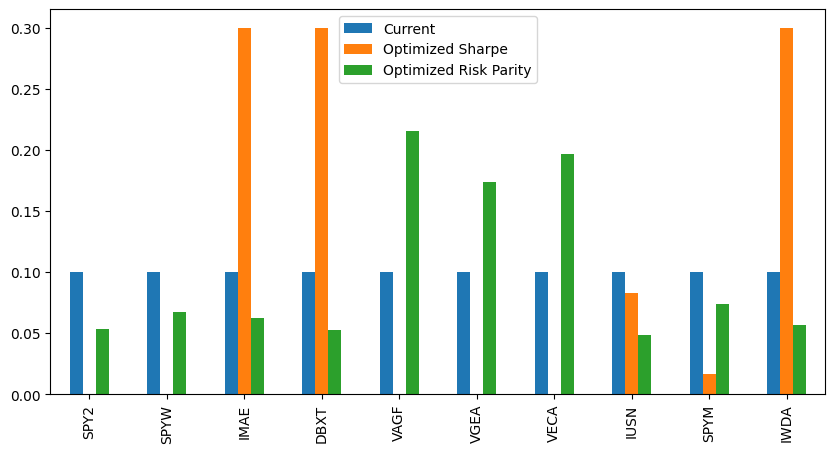

In [21]:
comparison = pd.DataFrame({"Current": weights, "Optimized Sharpe": weights_target_sharpe, "Optimized Risk Parity": weights_target_rp})
comparison.plot(kind="bar", figsize=(10,5))
plt.savefig("../outputs/charts/optimal_weights_comparison.png", dpi=300)

----------------------------------------------------------------------------------------
20. Portfolio rebalancing
----------------------------------------------------------------------------------------

In [22]:
rebalance_dates = returns.resample("YE").first().index
rebalance_dates = rebalance_dates.insert(0, returns.index[0])

portfolio_rp = pd.Series(index=returns.index, dtype=float)
portfolio_sharpe = pd.Series(index=returns.index, dtype=float)

weights_history_rp = {}
weights_history_sharpe = {}

min_lookback = 252 
valid_start = None

for date in rebalance_dates:
    window = returns.loc[:date].dropna()
    if len(window) >= min_lookback:
        valid_start = date
        break

current_weights_rp = np.ones(num_assets) / num_assets
current_weights_sh = np.ones(num_assets) / num_assets

for i in range(len(rebalance_dates) - 1):
    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    window = returns.loc[:start].ffill().dropna()
    if len(window) < min_lookback:
        continue

    mean_ret = window.mean() * 252
    cov = window.cov() * 252

    result_rp = minimize(risk_parity_objective, current_weights_rp, args=(cov,), method="SLSQP", bounds=bounds_rp, constraints=constraints_rp)
    w_rp = result_rp.x
    current_weights_rp = w_rp
    weights_history_rp[start] = w_rp

    result_sharpe = minimize(negative_sharpe, current_weights_sh, args=(mean_ret, cov, risk_free), method="SLSQP", bounds=bounds_sharpe, constraints=constraints_sharpe)
    w_sh = result_sharpe.x
    current_weights_sh = w_sh
    weights_history_sharpe[start] = w_sh

    period_returns = returns.loc[start:end].iloc[1:]
    portfolio_rp.loc[start:end] = period_returns.dot(w_rp)
    portfolio_sharpe.loc[start:end] = period_returns.dot(w_sh)

initial_weights = np.ones(num_assets) / num_assets

portfolio_rp.loc[:valid_start] = returns.loc[:valid_start].dot(initial_weights)
portfolio_sharpe.loc[:valid_start] = returns.loc[:valid_start].dot(initial_weights)

weights_df_rp = pd.DataFrame(weights_history_rp).T
weights_df_sharpe = pd.DataFrame(weights_history_sharpe).T

weights_df_rp.columns = returns.columns
weights_df_sharpe.columns = returns.columns
weights_df_rp = weights_df_rp.reindex(returns.index, method="ffill")
weights_df_sharpe = weights_df_sharpe.reindex(returns.index, method="ffill")
avg_weights_rp = weights_df_rp.mean()
avg_weights_sharpe = weights_df_sharpe.mean()

----------------------------------------------------------------------------------------
21. Portfolio optimized and rebalanced performance
----------------------------------------------------------------------------------------

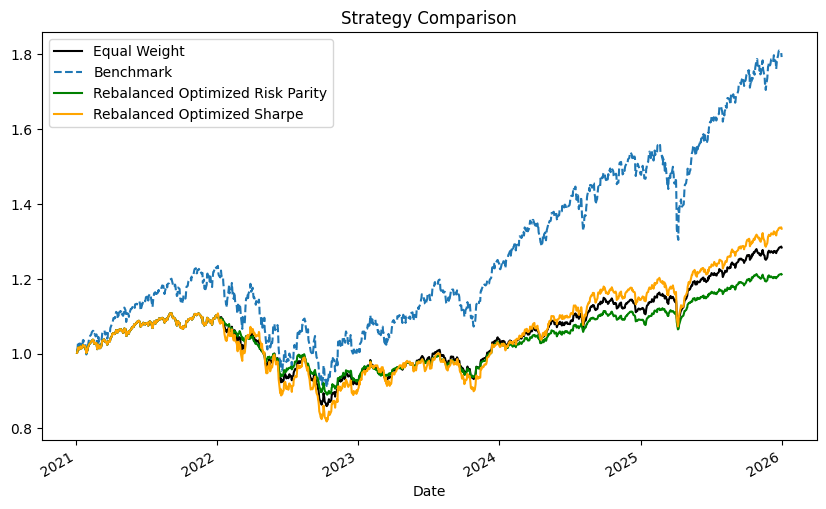

In [26]:
portfolio_rp = portfolio_rp.dropna()
portfolio_sharpe = portfolio_sharpe.dropna()
cum_rp = (1 + portfolio_rp).cumprod()
cum_sharpe = (1 + portfolio_sharpe).cumprod()
plt.figure(figsize=(10,6))

portfolio_cumulative_returns.plot(label="Equal Weight", color="black")
benchmark_cumulative_returns.plot(label="Benchmark", linestyle="--")
cum_rp.plot(label="Rebalanced Optimized Risk Parity", color="green")
cum_sharpe.plot(label="Rebalanced Optimized Sharpe", color="orange")

plt.legend()
plt.title("Strategy Comparison")
plt.savefig("../outputs/charts/strategy_comparison.png", dpi=300)

----------------------------------------------------------------------------------------
22. Strategies comparison
----------------------------------------------------------------------------------------

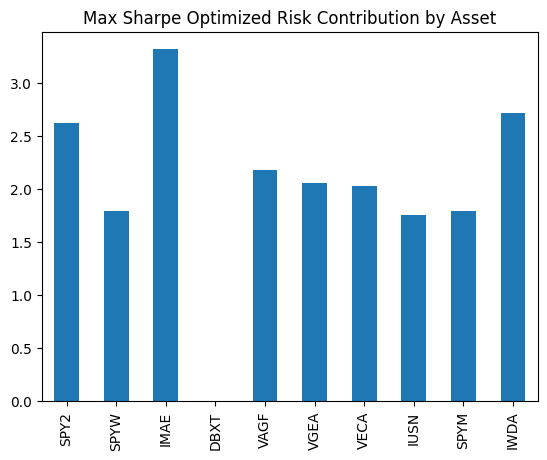

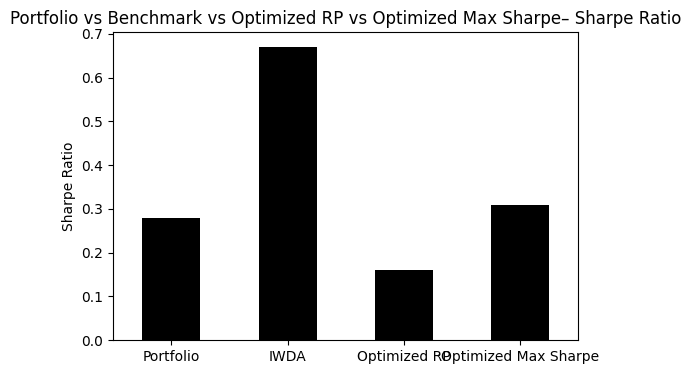

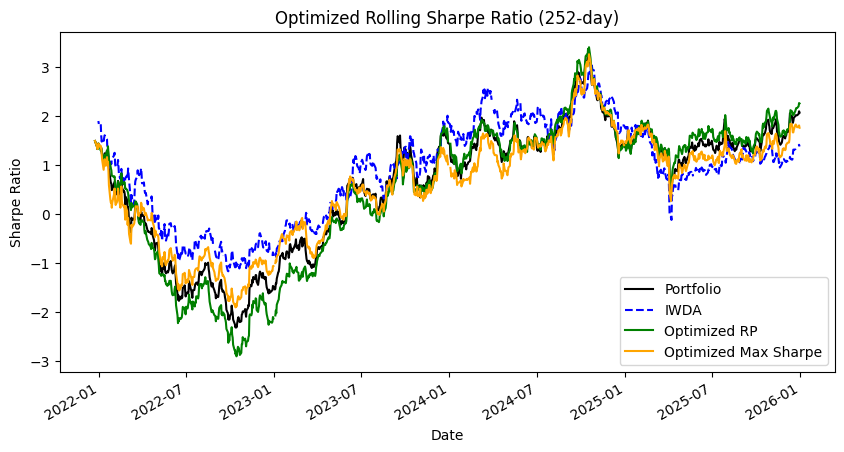

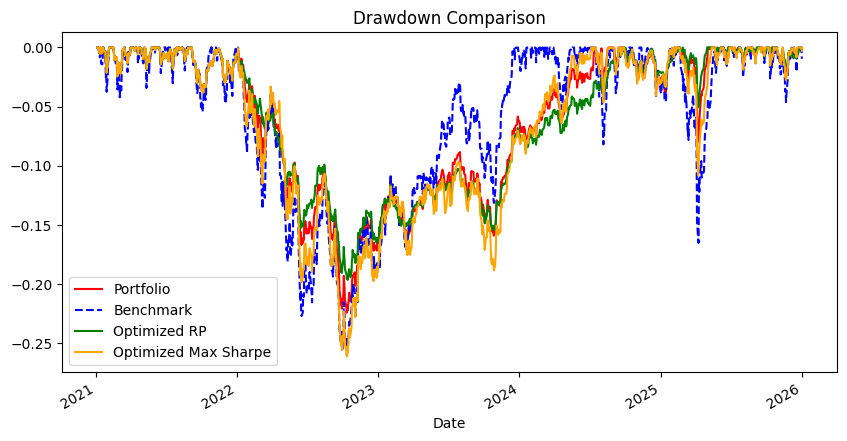

In [28]:
total_return_optimized_rp = cum_rp.iloc[-1] - 1
final_value_optimized_rp = cum_rp.iloc[-1] 
cagr_optimized_rp = final_value_optimized_rp ** (1 / n_years) - 1
volatility_optimized_rp = portfolio_rp.std() * np.sqrt(252)
total_return_optimized_sharpe = cum_sharpe.iloc[-1] - 1
final_value_optimized_sharpe = cum_sharpe.iloc[-1] 
cagr_optimized_sharpe = final_value_optimized_sharpe ** (1 / n_years) - 1
volatility_optimized_sharpe = portfolio_sharpe.std() * np.sqrt(252)

excess_returns_optimized_rp = portfolio_rp - rf_daily
sharpe_ratio_optimized_rp = (excess_returns_optimized_rp.mean() * 252) / volatility_optimized_rp
rolling_sharpe_optimized_rp = (portfolio_rp.rolling(252).mean() * 252) / (portfolio_rp.rolling(252).std() * np.sqrt(252))
excess_returns_optimized_sharpe = portfolio_sharpe - rf_daily
sharpe_ratio_optimized_sharpe = (excess_returns_optimized_sharpe.mean() * 252) / volatility_optimized_sharpe
rolling_sharpe_optimized_sharpe = (portfolio_sharpe.rolling(252).mean() * 252) / (portfolio_sharpe.rolling(252).std() * np.sqrt(252))

running_max_optimized_rp = cum_rp.cummax()
drawdown_optimized_rp = (cum_rp - running_max_optimized_rp) / running_max_optimized_rp
max_drawdown_optimized_rp = drawdown_optimized_rp.min()
running_max_optimized_sharpe = cum_sharpe.cummax()
drawdown_optimized_sharpe = (cum_sharpe - running_max_optimized_sharpe) / running_max_optimized_sharpe
max_drawdown_optimized_sharpe = drawdown_optimized_sharpe.min()

cov_matrix_optimized_rp = returns.cov() * 252
portfolio_var_optimized_rp = avg_weights_rp.T @ cov_matrix_optimized_rp @ avg_weights_rp
marginal_contribution_optimized_rp = cov_matrix_optimized_rp @ avg_weights_rp
risk_contribution_optimized_rp = avg_weights_rp * marginal_contribution_optimized_rp / portfolio_var_optimized_rp
risk_contribution_pct_optimized_rp = risk_contribution_optimized_rp / volatility_optimized_rp
risk_contribution_optimized_rp_df = pd.DataFrame({"Weight": avg_weights_rp, "Risk Parity Risk Contribution": risk_contribution_optimized_rp, "Risk Parity Optimized Risk Contribution %": risk_contribution_pct_optimized_rp}, index=returns.columns)
risk_contribution_optimized_rp_df["Risk Parity Optimized Risk Contribution %"].plot(kind="bar")
plt.title("Risk Parity Optimized Risk Contribution by Asset")
plt.savefig("../outputs/charts/asset_risk_contribution_optimized_rp.png", dpi=300)
cov_matrix_optimized_sharpe = returns.cov() * 252
portfolio_var_optimized_sharpe = avg_weights_sharpe.T @ cov_matrix_optimized_sharpe @ avg_weights_sharpe
marginal_contribution_optimized_sharpe = cov_matrix_optimized_sharpe @ avg_weights_sharpe
risk_contribution_optimized_sharpe = avg_weights_sharpe * marginal_contribution_optimized_sharpe / portfolio_var_optimized_sharpe
risk_contribution_pct_optimized_sharpe = risk_contribution_optimized_sharpe / volatility_optimized_sharpe
risk_contribution_optimized_sharpe_df = pd.DataFrame({"Weight": avg_weights_sharpe, "Max Sharpe Risk Contribution": risk_contribution_optimized_sharpe, "Max Sharpe Optimized Risk Contribution %": risk_contribution_pct_optimized_sharpe}, index=returns.columns)
risk_contribution_optimized_sharpe_df["Max Sharpe Optimized Risk Contribution %"].plot(kind="bar")
plt.title("Max Sharpe Optimized Risk Contribution by Asset")
plt.savefig("../outputs/charts/asset_risk_contribution_optimized_sharpe.png", dpi=300)

sharpe_comparison_optimized = pd.DataFrame({"Optimized Sharpe Ratio": [sharpe_ratio, benchmark_sharpe, sharpe_ratio_optimized_rp, sharpe_ratio_optimized_sharpe]}, index=["Portfolio", "IWDA", "Optimized RP", "Optimized Max Sharpe"])
sharpe_comparison_optimized = sharpe_comparison_optimized.round(2)
sharpe_comparison_optimized.plot(kind="bar", figsize=(6,4), legend=False, color=["black", "blue", "red", "green"]) 
plt.title("Portfolio vs Benchmark vs Optimized RP vs Optimized Max Sharpe– Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=0)
plt.savefig("../outputs/charts/optimized_sharpe_comparison.png", dpi=300)

rolling_sharpe_optimized_comparison = pd.DataFrame({"Optimized Rolling Sharpe Ratio": [rolling_sharpe, benchmark_rolling_sharpe, rolling_sharpe_optimized_rp, rolling_sharpe_optimized_sharpe]}, index=["Portfolio", "IWDA", "Optimized RP", "Optimized Max Sharpe"])
rolling_sharpe_optimized_comparison = rolling_sharpe_optimized_comparison.round(2)
rolling_sharpe_optimized_comparison = pd.DataFrame({"Portfolio": rolling_sharpe, "IWDA": benchmark_rolling_sharpe, "Optimized RP": rolling_sharpe_optimized_rp, "Optimized Max Sharpe": rolling_sharpe_optimized_sharpe})
rolling_sharpe_optimized_comparison.plot(figsize=(10,5), color={"Portfolio": "black", "IWDA": "blue", "Optimized RP": "green", "Optimized Max Sharpe": "orange"}, style={"IWDA": "--"})
plt.title("Optimized Rolling Sharpe Ratio (252-day)")
plt.ylabel("Sharpe Ratio")
plt.savefig("../outputs/charts/optimized_rolling_sharpe_comparison.png", dpi=300)

max_drawdown_optimized_comparison = pd.DataFrame({"Max Drawdown": [drawdown.min(),benchmark_drawdown.min(), drawdown_optimized_rp.min(), drawdown_optimized_sharpe.min()]}, index=['Portfolio', "IWDA", "Optimized RP", "Optimized Max Sharpe"])
max_drawdown_optimized_comparison = max_drawdown_optimized_comparison.round(2)
plt.figure(figsize = (10,5))
drawdown.plot(label = "Portfolio", color = "red") 
benchmark_drawdown.plot(label = "Benchmark", color = "blue", linestyle = "--")
drawdown_optimized_rp.plot(label = "Optimized RP", color = "green")
drawdown_optimized_sharpe.plot(label = "Optimized Max Sharpe", color = "orange")
plt.title("Drawdown Comparison")
plt.legend()
plt.savefig("../outputs/charts/optimized_drawdown_comparison.png", dpi=300)

sharpe_tolerance = 0.05
drawdown_tolerance = 0.01
optimized_sharpe_difference_rp = sharpe_ratio_optimized_rp - benchmark_sharpe 
optimized_rolling_sharpe_difference_rp = (rolling_sharpe_optimized_rp.mean() - benchmark_rolling_sharpe.mean())
optimized_drawdown_difference_rp = max_benchmark_drawdown - max_drawdown_optimized_rp
optimized_concentration_rp = risk_contribution_pct_optimized_rp.max()
optimized_sharpe_difference_sharpe = sharpe_ratio_optimized_sharpe - benchmark_sharpe 
optimized_rolling_sharpe_difference_sharpe = (rolling_sharpe_optimized_sharpe.mean() - benchmark_rolling_sharpe.mean())
optimized_drawdown_difference_sharpe = max_benchmark_drawdown - max_drawdown_optimized_sharpe
optimized_concentration_sharpe = risk_contribution_pct_optimized_sharpe.max()

if optimized_sharpe_difference_rp > sharpe_tolerance:
    optimized_sharpe_result_rp = "Optimized Risk Parity Portfolio outperformed the Benchmark"
elif optimized_sharpe_difference_rp < -sharpe_tolerance:
    optimized_sharpe_result_rp = "Optimized Risk Parity Portfolio underperformed the Benchmark" 
else:
    optimized_sharpe_result_rp = "Optimized Risk Parity Portfolio performed in line with the Benchmark" 
if optimized_rolling_sharpe_difference_rp > sharpe_tolerance:
    optimized_rolling_sharpe_result_rp = "Optimized Risk Parity Portfolio outperformed the Benchmark"
elif optimized_rolling_sharpe_difference_rp < -sharpe_tolerance:
    optimized_rolling_sharpe_result_rp = "Optimized Risk Parity Portfolio underperformed the Benchmark" 
else:
    optimized_rolling_sharpe_result_rp = "Optimized Risk Parity Portfolio performed in line with the Benchmark"
if optimized_drawdown_difference_rp > drawdown_tolerance:
    optimized_drawdown_result_rp = "Optimized Risk Parity Portfolio had worse downside than the Benchmark"
elif optimized_drawdown_difference_rp < - drawdown_tolerance:
    optimized_drawdown_result_rp = "Optimized Risk Parity Portfolio had better downside protection than the Benchmark"
else:
    optimized_drawdown_result_rp = "Optimized Risk Parity Portfolio drawdown was in line with the Benchmark"
if optimized_concentration_rp > 0.4:
    optimized_risk_result_rp = "Optimized Risk Parity Portfolio risk is highly concentrated"
elif optimized_concentration_rp < 0.2:
    optimized_risk_result_rp = "Optimized Risk Parity Portfolio risk is well diversified"
else:
    optimized_risk_result_rp = "Optimized Risk Parity Portfolio has moderate risk concentration"

if optimized_sharpe_difference_sharpe > sharpe_tolerance:
    optimized_sharpe_result_sharpe = "Optimized Max Sharpe Portfolio outperformed the Benchmark"
elif optimized_sharpe_difference_sharpe < -sharpe_tolerance:
    optimized_sharpe_result_sharpe = "Optimized Max Sharpe Portfolio underperformed the Benchmark" 
else:
    optimized_sharpe_result_sharpe = "Optimized Max Sharpe Portfolio performed in line with the Benchmark" 
if optimized_rolling_sharpe_difference_sharpe > sharpe_tolerance:
    optimized_rolling_sharpe_result_sharpe = "Optimized Max Sharpe Portfolio outperformed the Benchmark"
elif optimized_rolling_sharpe_difference_sharpe < -sharpe_tolerance:
    optimized_rolling_sharpe_result_sharpe = "Optimized Max Sharpe Portfolio underperformed the Benchmark" 
else:
    optimized_rolling_sharpe_result_sharpe = "Optimized Max Sharpe Portfolio performed in line with the Benchmark"
if optimized_drawdown_difference_sharpe > drawdown_tolerance:
    optimized_drawdown_result_sharpe = "Optimized Max Sharpe Portfolio had worse downside than the Benchmark"
elif optimized_drawdown_difference_sharpe < - drawdown_tolerance:
    optimized_drawdown_result_sharpe = "Optimized Max Sharpe Portfolio had better downside protection than the Benchmark"
else:
    optimized_drawdown_result_sharpe = "Optimized Max Sharpe Portfolio drawdown was in line with the Benchmark"
if optimized_concentration_sharpe > 0.4:
    optimized_risk_result_sharpe = "Optimized Max Sharpe Portfolio risk is highly concentrated"
elif optimized_concentration_sharpe < 0.2:
    optimized_risk_result_sharpe = "Optimized Max Sharpe Portfolio risk is well diversified"
else:
    optimized_risk_result_sharpe = "Optimized Max Sharpe Portfolio has moderate risk concentration"

optimized_sharpe_difference_original_rp = sharpe_ratio_optimized_rp - sharpe_ratio 
optimized_rolling_sharpe_difference_original_rp = (rolling_sharpe_optimized_rp.mean() - rolling_sharpe.mean())
optimized_drawdown_difference_original_rp = max_drawdown - max_drawdown_optimized_rp
optimized_sharpe_difference_original_sharpe = sharpe_ratio_optimized_sharpe - sharpe_ratio 
optimized_rolling_sharpe_difference_original_sharpe = (rolling_sharpe_optimized_sharpe.mean() - rolling_sharpe.mean())
optimized_drawdown_difference_original_sharpe = max_drawdown - max_drawdown_optimized_sharpe

if optimized_sharpe_difference_original_rp > sharpe_tolerance:
    optimized_sharpe_result_original_rp = "Optimized Risk Parity Portfolio outperformed the Original Portfolio"
elif optimized_sharpe_difference_original_rp < -sharpe_tolerance:
    optimized_sharpe_result_original_rp = "Optimized Risk Parity Portfolio underperformed the Original Portfolio" 
else:
    optimized_sharpe_result_original_rp = "Optimized Risk Parity Portfolio performed in line with the Original Portfolio" 
if optimized_rolling_sharpe_difference_original_rp > sharpe_tolerance:
    optimized_rolling_sharpe_result_original_rp = "Optimized Risk Parity Portfolio outperformed the Original Portfolio"
elif optimized_rolling_sharpe_difference_original_rp < -sharpe_tolerance:
    optimized_rolling_sharpe_result_original_rp = "Optimized Risk Parity Portfolio underperformed the Original Portfolio" 
else:
    optimized_rolling_sharpe_result_original_rp = "Optimized Risk Parity Portfolio performed in line with the Original Portfolio"
if optimized_drawdown_difference_original_rp > drawdown_tolerance:
    optimized_drawdown_result_original_rp = "Optimized Risk Parity Portfolio had worse downside than the Original Portfolio"
elif optimized_drawdown_difference_original_rp < - drawdown_tolerance:
    optimized_drawdown_result_original_rp = "Optimized Risk Parity Portfolio had better downside protection than the Original Portfolio"
else:
    optimized_drawdown_result_original_rp = "Optimized Risk Parity Portfolio drawdown was in line with the Original Portfolio"

if optimized_sharpe_difference_original_sharpe > sharpe_tolerance:
    optimized_sharpe_result_original_sharpe = "Optimized Max Sharpe Portfolio outperformed the Original Portfolio"
elif optimized_sharpe_difference_original_sharpe < -sharpe_tolerance:
    optimized_sharpe_result_original_sharpe = "Optimized Max Sharpe Portfolio underperformed the Original Portfolio" 
else:
    optimized_sharpe_result_original_sharpe = "Optimized Max Sharpe Portfolio performed in line with the Original Portfolio" 
if optimized_rolling_sharpe_difference_original_sharpe > sharpe_tolerance:
    optimized_rolling_sharpe_result_original_sharpe = "Optimized Max Sharpe Portfolio outperformed the Original Portfolio"
elif optimized_rolling_sharpe_difference_original_sharpe < -sharpe_tolerance:
    optimized_rolling_sharpe_result_original_sharpe = "Optimized Max Sharpe Portfolio underperformed the Original Portfolio" 
else:
    optimized_rolling_sharpe_result_original_sharpe = "Optimized Max Sharpe Portfolio performed in line with the Original Portfolio"
if optimized_drawdown_difference_original_sharpe > drawdown_tolerance:
    optimized_drawdown_result_original_sharpe = "Optimized Max Sharpe Portfolio had worse downside than the Original Portfolio"
elif optimized_drawdown_difference_original_sharpe < - drawdown_tolerance:
    optimized_drawdown_result_original_sharpe = "Optimized Max Sharpe Portfolio had better downside protection than the Original Portfolio"
else:
    optimized_drawdown_result_original_sharpe = "Optimized Max Sharpe Portfolio drawdown was in line with the Original Portfolio"


----------------------------------------------------------------------------------------
23. Summary of calculated metrics
----------------------------------------------------------------------------------------

In [29]:
print("\n=== PORTFOLIO SUMMARY ===\n")
print("Portfolio Total return: {}".format(total_return))
print("Portfolio CAGR: {}" .format(cagr))
print("Portfolio Volatility: {}" .format(volatility))
print("Portfolio Sharpe Ratio: {}" .format(sharpe_ratio))
print("Portfolio Rolling Sharpe Ratio: {}" .format(rolling_sharpe.mean()))
print("Portfolio Max Drawdown: {}" .format(max_drawdown))
print("\n=== BENCHMARK SUMMARY ===\n")
print("Benchmark Total return: {}" .format(total_benchmark_return)) 
print("Benchmark CAGR: {}" .format(benchmark_cagr))
print("Benchmark Volatility: {}" .format(benchmark_volatility)) 
print("Benchmark Sharpe Ratio: {}" .format(benchmark_sharpe))
print("Benchmark Rolling Sharpe Ratio: {}" .format(benchmark_rolling_sharpe.mean())) 
print("Benchmark Max Drawdown: {}" .format(max_benchmark_drawdown))
print("\n=== OPTIMIZED RISK PARITY PORTFOLIO SUMMARY ===\n")
print("Optimized Portfolio Total return: {}" .format(total_return_optimized_rp)) 
print("Optimized Portfolio CAGR: {}" .format(cagr_optimized_rp))
print("Optimized Portfolio Volatility: {}" .format(volatility_optimized_rp)) 
print("Optimized Portfolio Sharpe Ratio: {}" .format(sharpe_ratio_optimized_rp))
print("Optimized Portfolio Rolling Sharpe Ratio: {}" .format(rolling_sharpe_optimized_rp.mean())) 
print("Optimized Portfolio Max Drawdown: {}" .format(max_drawdown_optimized_rp))
print("\n=== OPTIMIZED MAX SHARPE PORTFOLIO SUMMARY ===\n")
print("Optimized Portfolio Total return: {}" .format(total_return_optimized_sharpe)) 
print("Optimized Portfolio CAGR: {}" .format(cagr_optimized_sharpe))
print("Optimized Portfolio Volatility: {}" .format(volatility_optimized_sharpe)) 
print("Optimized Portfolio Sharpe Ratio: {}" .format(sharpe_ratio_optimized_sharpe))
print("Optimized Portfolio Rolling Sharpe Ratio: {}" .format(rolling_sharpe_optimized_sharpe.mean())) 
print("Optimized Portfolio Max Drawdown: {}" .format(max_drawdown_optimized_sharpe))
print("\n=== PERFORMANCE ASSESSMENT (Original vs Benchmark)===\n")
print("Sharpe comparison: {}" .format(sharpe_result))
print("Rolling Sharpe comparison: {}" .format(rolling_sharpe_result)) 
print("Drawdown comparison: {}" .format(drawdown_result))
print("Risk Concentration: {}" .format(risk_result))
print("\n=== PERFORMANCE ASSESSMENT (Optimized Risk Parity vs Benchmark)===\n")
print("Sharpe comparison: {}" .format(optimized_sharpe_result_rp))
print("Rolling Sharpe comparison: {}" .format(optimized_rolling_sharpe_result_rp)) 
print("Drawdown comparison: {}" .format(optimized_drawdown_result_rp))
print("Risk Concentration: {}" .format(optimized_risk_result_rp))
print("\n=== PERFORMANCE ASSESSMENT (Optimized Max Sharpe vs Benchmark)===\n")
print("Sharpe comparison: {}" .format(optimized_sharpe_result_sharpe))
print("Rolling Sharpe comparison: {}" .format(optimized_rolling_sharpe_result_sharpe)) 
print("Drawdown comparison: {}" .format(optimized_drawdown_result_sharpe))
print("Risk Concentration: {}" .format(optimized_risk_result_sharpe))
print("\n=== PERFORMANCE ASSESSMENT (Optimized Risk Parity vs Original)===\n")
print("Sharpe comparison: {}" .format(optimized_sharpe_result_original_rp))
print("Rolling Sharpe comparison: {}" .format(optimized_rolling_sharpe_result_original_rp))
print("Drawdown comparison: {}" .format(optimized_drawdown_result_original_rp))
print("\n=== PERFORMANCE ASSESSMENT (Optimized Max Sharpe vs Original)===\n")
print("Sharpe comparison: {}" .format(optimized_sharpe_result_original_sharpe))
print("Rolling Sharpe comparison: {}" .format(optimized_rolling_sharpe_result_original_sharpe))
print("Drawdown comparison: {}" .format(optimized_drawdown_result_original_sharpe))



=== PORTFOLIO SUMMARY ===

Portfolio Total return: 0.2835926880761661
Portfolio CAGR: 0.04986145222242455
Portfolio Volatility: 0.0758450984951531
Portfolio Sharpe Ratio: 0.2844928509427696
Portfolio Rolling Sharpe Ratio: 0.6169021607849994
Portfolio Max Drawdown: -0.2244630686572023

=== BENCHMARK SUMMARY ===

Benchmark Total return: 0.7931508733324126
Benchmark CAGR: 0.12054371113778672
Benchmark Volatility: 0.14446282689117143
Benchmark Sharpe Ratio: 0.6719266231492902
Benchmark Rolling Sharpe Ratio: 0.8837987432482192
Benchmark Max Drawdown: -0.260360962566845

=== OPTIMIZED RISK PARITY PORTFOLIO SUMMARY ===

Optimized Portfolio Total return: 0.21178926379794527
Optimized Portfolio CAGR: 0.03814872303141481
Optimized Portfolio Volatility: 0.05892704792323781
Optimized Portfolio Sharpe Ratio: 0.15771521305781497
Optimized Portfolio Rolling Sharpe Ratio: 0.5356157501704137
Optimized Portfolio Max Drawdown: -0.19668153308199826

=== OPTIMIZED MAX SHARPE PORTFOLIO SUMMARY ===

Optimiz